# Tech Challenge — Fases 3, 4 e 5: Modelagem Supervisionada, Benchmark e Explicabilidade SHAP
**POSTECH / FIAP — AI Scientist**

Esteira preditiva completa sobre os microdados do Indicador Criança Alfabetizada (INEP):

1. **Fase 3** — Consumo da ABT da camada Gold, particionamento 70/15/15 e blindagem contra *data leakage*;
2. **Fase 4** — Benchmark de 5 algoritmos, sintonia de hiperparâmetros e avaliação no conjunto de teste;
3. **Fase 5** — Interpretabilidade com SHAP (Beeswarm, Bar, Dependence e Waterfall);
4. **Respostas de negócio** geradas a partir dos resultados calculados.

---



## 1. Ambiente, dependências e parâmetros de execução

Roda no **Google Colab** (autentica na sua conta Google) e também localmente
(usa as credenciais do `gcloud auth application-default login`).

In [1]:
import os
import sys
import warnings

warnings.filterwarnings("ignore")

# Garante que os gráficos fiquem embutidos no notebook, e não só salvos em disco
%matplotlib inline

# ============================ PARÂMETROS ============================
PROJETO_GCP = "tech-challenge-alfabetiza-25"
DATASET_GOLD = "gold"   # a Fase 3 consome exclusivamente a camada Gold

# Restringe a ABT a um único ano. None = todos os anos disponíveis no modo escolhido.
# Se o Colab ficar sem RAM, use 2024.
ANO_FILTRO = None

# COMO OS INDICADORES MUNICIPAIS/ESTADUAIS SÃO MONTADOS. Leia a seção 2.2.
#   "ano_anterior" (padrão) -> usa as colunas *_ant da Gold: indicador do ano
#                              ANTERIOR ao do aluno, sem vazamento do alvo. Como só
#                              há 2023 como ano de referência, restam os alunos de
#                              2024 (1.817.470 linhas).
#   "mesmo_ano"             -> usa as colunas sem sufixo: indicador do mesmo ano.
#                              Cobre 2023 e 2024 (3.354.661), mas o indicador contém
#                              o próprio alvo agregado. Só para análise descritiva.
MODO_INDICADOR = "ano_anterior"

# Quantas linhas usar para TREINAR. O conjunto de validação e o de teste
# continuam íntegros — o corte vale só para o treino, que é a parte cara.
# Justificativa medida: com 200 mil linhas o ROC-AUC foi 0,6708; com as
# 3,35 milhões foi 0,6769. A diferença (0,006) não paga o tempo de máquina.
N_TREINO_MAX = 300_000

# Amostra usada na sintonia de hiperparâmetros (RandomizedSearchCV, 5 folds).
N_TUNING = 100_000
N_ITER_TUNING = 10

# Quantos registros explicar com SHAP (ver a seção 7 para o critério de escolha).
N_SHAP = 8_000

# Incluir as variáveis socioeconômicas (IDHM, PIB, Gini, porte). Leia o aviso
# da seção 2.3 antes de interpretar a importância delas.
INCLUIR_SOCIO = True

SEED = 42
# ====================================================================

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Google Colab detectado. Configurando o ambiente...")
    from google.colab import auth

    auth.authenticate_user()
    print("  - Autenticado na conta Google.")

    print("  - Instalando dependências (~1 min)...")
    os.system(
        "pip install -q lightgbm xgboost shap db-dtypes "
        "google-cloud-bigquery-storage pyarrow"
    )
    print("  - Dependências instaladas.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery

from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, average_precision_score,
    brier_score_loss, confusion_matrix, f1_score, precision_recall_curve,
    precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import (
    RandomizedSearchCV, StratifiedKFold, train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import joblib

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

for pasta in ("images/evaluation", "images/shap", "artifacts", "data"):
    os.makedirs(pasta, exist_ok=True)

client = bigquery.Client(project=PROJETO_GCP)

print()
print("=" * 66)
print(f"Ambiente pronto.  Projeto: {PROJETO_GCP}")
print(f"LightGBM: {'sim' if HAS_LGBM else 'nao'} | "
      f"XGBoost: {'sim' if HAS_XGB else 'nao'} | "
      f"SHAP: {'sim' if HAS_SHAP else 'nao'}")
print(f"Indicador municipal: {MODO_INDICADOR} | Ano: {ANO_FILTRO or 'todos'}")
print(f"Teto de treino: {N_TREINO_MAX:,} linhas")
print("=" * 66)


Ambiente pronto.  Projeto: tech-challenge-alfabetiza-25
LightGBM: sim | XGBoost: sim | SHAP: sim
Indicador municipal: ano_anterior | Ano: todos
Teto de treino: 300,000 linhas


## 2. Carregamento da camada Gold (`gold.abt_alfabetizacao`)

### 2.1 De onde vem o dado

A ABT é construída pelo **pipeline da Fase 2**, como um mart da camada Gold, junto dos
demais. Este notebook apenas **consome** essa tabela — nenhum CSV local, nenhuma
transformação de origem aqui.

```
gold/
├── mart_comparativo_municipio   (24.070)   -> dashboards, BI
├── mart_comparativo_uf             (179)   -> dashboards, BI
├── mart_comparativo_brasil           (8)   -> dashboards, BI
├── mart_frescor_streaming            (2)   -> observabilidade
└── abt_alfabetizacao         (3.354.661)   -> treinamento de ML   <- consumida aqui
```

O grão é **o aluno avaliado no 2º ano do Ensino Fundamental**, filtrado pelo público
elegível (`presenca = 1` e `preenchimento_caderno = 1`). O pipeline valida, a cada
execução, que a contagem bate exatamente com o elegível da camada Silver.

### 2.2 As duas famílias de indicadores — e por que isso importa

A Gold entrega os indicadores municipais e estaduais em **duas versões**, e escolher a
errada compromete todo o resultado.

A coluna `mun_taxa_alfabetizacao` vem da avaliação municipal do INEP **do mesmo ano do
aluno**. Só que essa taxa é, por definição, a média do alvo naquele município — com o
próprio aluno dentro dela. A correlação medida entre as duas é **0,993**. Não é contexto:
é o rótulo agregado. Usá-la como feature é *target leakage* por agregação.

Por isso a Gold traz também as colunas com sufixo **`_ant`**, com o indicador do **ano
anterior**. Essas não contêm o alvo do aluno e são as únicas próprias para modelagem.

**O tamanho real do problema** (LightGBM, alunos de 2024, amostra de 400 mil):

| Indicador municipal | ROC-AUC | PR-AUC |
|---|---|---|
| Do mesmo ano (com vazamento) | 0,6806 | 0,7601 |
| **Do ano anterior (`_ant`)** | **0,6641** | **0,7438** |
| Nenhum indicador municipal | 0,6369 | 0,7169 |

O vazamento valia apenas 0,017 de ROC-AUC. O modelo se sustenta sem ele — e passa a ser
defensável. É também como o modelo funcionaria na vida real: para olhar o ano que vem,
só existe o resultado do ano passado.

O custo é que 2023 sai da modelagem (não há 2022 como referência), e saem também Acre e
Distrito Federal, cujos municípios não aparecem na avaliação de 2023. Restam
**1.817.470 alunos**, 24 UFs e 5.481 municípios.

In [2]:
SQL_GOLD = """
SELECT *
FROM `{projeto}.{gold}.abt_alfabetizacao`
WHERE TRUE
  {filtro_modo}
  {filtro_ano}
"""

# Colunas com as duas versões do indicador. A da esquerda (sem sufixo) é do mesmo
# ano do aluno; a da direita (_ant) é do ano anterior. O notebook renomeia a
# família escolhida para o nome curto, de modo que o restante do código não
# precise saber qual foi usada.
_PARES_INDICADOR = [
    ("mun_taxa_alfabetizacao",      "mun_taxa_alfabetizacao_ant"),
    ("mun_media_portugues",         "mun_media_portugues_ant"),
    ("mun_nivel_alfabetizacao",     "mun_nivel_alfabetizacao_ant"),
    ("mun_percentual_participacao", "mun_percentual_participacao_ant"),
    ("mun_gap_meta_2024",           "mun_gap_meta_2024_ant"),
    ("uf_taxa_alfabetizacao",       "uf_taxa_alfabetizacao_ant"),
    ("uf_media_portugues",          "uf_media_portugues_ant"),
    ("razao_mun_uf_taxa",           "razao_mun_uf_taxa_ant"),
]


def carregar_abt_gold(client, projeto, gold, modo=MODO_INDICADOR, ano=None):
    """Lê a ABT da camada Gold e seleciona a família de indicadores pedida."""
    if modo not in ("ano_anterior", "mesmo_ano"):
        raise ValueError('MODO_INDICADOR deve ser "ano_anterior" ou "mesmo_ano"')

    # No modo sem vazamento, só interessam os alunos cujo município tem
    # indicador do ano anterior disponível.
    filtro_modo = ("AND mun_taxa_alfabetizacao_ant IS NOT NULL"
                   if modo == "ano_anterior" else "")

    sql = SQL_GOLD.format(
        projeto=projeto, gold=gold,
        filtro_modo=filtro_modo,
        filtro_ano=f"AND ano = {int(ano)}" if ano is not None else "",
    )
    job = client.query(sql)
    df = job.result().to_dataframe()
    mb = (job.total_bytes_processed or 0) / 1024 / 1024
    print(f"Lido de {projeto}.{gold}.abt_alfabetizacao: "
          f"{len(df):,} linhas | {mb:,.0f} MB escaneados")
    print(f"  modo de indicador: {modo}")

    # Mantém só a família escolhida e devolve os nomes curtos
    mesmo_ano = [par[0] for par in _PARES_INDICADOR]
    ano_anterior = [par[1] for par in _PARES_INDICADOR]
    if modo == "ano_anterior":
        df = df.drop(columns=mesmo_ano)
        df = df.rename(columns=dict(zip(ano_anterior, mesmo_ano)))
    else:
        df = df.drop(columns=ano_anterior)

    return df


df = carregar_abt_gold(client, PROJETO_GCP, DATASET_GOLD, MODO_INDICADOR, ANO_FILTRO)

# Reduz o consumo de memória: colunas de texto viram categorias e floats de 64
# bits viram 32 bits. Corta o uso pela metade sem perder precisão relevante.
for col in ("id_municipio", "nome_municipio", "sigla_uf", "nome_regiao",
            "rede_label", "porte_municipio"):
    df[col] = df[col].astype("category")
for col in df.select_dtypes("float").columns:
    df[col] = df[col].astype("float32")
df["alfabetizado"] = df["alfabetizado"].astype("int8")
df = df.drop(columns=["_processed_at"], errors="ignore").reset_index(drop=True)

print(f"\nMemória ocupada: {df.memory_usage(deep=True).sum() / 1024**2:,.0f} MB")
print(f"Anos presentes: {sorted(df.ano.unique())}")
print(f"Municípios: {df.id_municipio.nunique():,} | "
      f"UFs: {df.sigla_uf.nunique()} | Escolas: {df.id_escola.nunique():,}")
print(f"Chave (ano, id_aluno) duplicada: {df.duplicated(['ano', 'id_aluno']).sum()}")
print(f"Alvo nulo: {df.alfabetizado.isna().sum()} | "
      f"Taxa de alfabetizados: {df.alfabetizado.mean() * 100:.2f}%")
df.head()

Lido de tech-challenge-alfabetiza-25.gold.abt_alfabetizacao: 1,817,470 linhas | 0 MB escaneados
  modo de indicador: ano_anterior



Memória ocupada: 438 MB
Anos presentes: [np.int64(2024)]
Municípios: 5,481 | UFs: 24 | Escolas: 41,677


Chave (ano, id_aluno) duplicada: 0
Alvo nulo: 0 | Taxa de alfabetizados: 59.83%


,ano,id_municipio,nome_municipio,sigla_uf,nome_regiao,id_escola,id_aluno,caderno,serie,rede_label,...,mun_taxa_alfabetizacao,mun_media_portugues,mun_nivel_alfabetizacao,mun_percentual_participacao,mun_gap_meta_2024,uf_taxa_alfabetizacao,uf_media_portugues,razao_mun_uf_taxa,proficiencia_audit_only,alfabetizado
0,2024,3300605,Bom Jesus do Itabapoana,RJ,Sudeste,60023141,33036070,16,2,Municipal,...,57.91,743.686707,2.0,76.599998,-3.66,52.130001,737.303223,1.1109,752.890015,1
1,2024,3300605,Bom Jesus do Itabapoana,RJ,Sudeste,60023141,33036042,10,2,Municipal,...,57.91,743.686707,2.0,76.599998,-3.66,52.130001,737.303223,1.1109,776.340027,1
2,2024,3300605,Bom Jesus do Itabapoana,RJ,Sudeste,60023141,33036069,15,2,Municipal,...,57.91,743.686707,2.0,76.599998,-3.66,52.130001,737.303223,1.1109,742.020020,0
3,2024,3300605,Bom Jesus do Itabapoana,RJ,Sudeste,60023142,33036123,19,2,Municipal,...,57.91,743.686707,2.0,76.599998,-3.66,52.130001,737.303223,1.1109,777.390015,1
4,2024,3300605,Bom Jesus do Itabapoana,RJ,Sudeste,60023144,33035997,11,2,Municipal,...,57.91,743.686707,2.0,76.599998,-3.66,52.130001,737.303223,1.1109,801.909973,1


### 2.3 Variáveis socioeconômicas municipais — leia antes de interpretar

As colunas `idhm`, `idhm_educacao`, `idhm_renda`, `idhm_longevidade`, `pib_per_capita`,
`indice_gini`, `taxa_abandono_fundamental`, `populacao_estimada` e `porte_municipio` vêm
da dimensão `silver.dim_socioeconomico_municipio` e **não são de fonte oficial**. São
geradas por sorteio determinístico (semente derivada do código IBGE do município) em
torno das médias regionais do Atlas do Desenvolvimento Humano. A própria tabela carrega
esse aviso na descrição, e cada linha é marcada com `origem_dado = 'SINTETICO_CALIBRADO_REGIONAL'`.

**A consequência prática, medida sobre a base completa:**

| Conjunto de features | ROC-AUC |
|---|---|
| Tudo (reais da Fase 2 + socioeconômicas) | 0,6731 |
| **Só as reais da Fase 2** (+ UF / região / rede) | **0,6735** |
| Só as socioeconômicas | 0,6386 |
| Só o contexto territorial (UF / região / rede) | 0,6318 |

As socioeconômicas **contribuem zero** — na verdade, tiram 0,0004. E sozinhas (0,6386)
mal superam "só a região" (0,6318), porque foi exatamente assim que foram construídas:
ruído em torno da média da região. Na prática, `idhm_educacao` aqui é um sinônimo
embaralhado de `nome_regiao`.

**Nenhuma conclusão sobre IDHM, PIB ou Gini deste notebook deve ir para o relatório final
como achado de política pública.** Para valer, é preciso trocar a dimensão por IDHM real
do Atlas Brasil e PIB municipal do IBGE/SIDRA — o que é uma troca de uma tabela só, sem
mexer no resto do pipeline.

Mantemos as colunas para preservar o escopo do enunciado (que cita variáveis
socioeconômicas explicitamente), e o SHAP separa o que é real do que é sintético.

## 3. Fase 3: Particionamento e blindagem contra *data leakage*

* Divisão **70% treino / 15% validação / 15% teste**, estratificada por `alfabetizado`.
* O `ColumnTransformer` é ajustado (`.fit`) **exclusivamente no conjunto de treino** e
  apenas aplicado (`.transform`) em validação e teste, dentro do mesmo `Pipeline`.
  É isso que garante que nenhuma estatística do teste vaze para o pré-processamento.
* Ficam **fora** das features: `proficiencia_audit_only` (define o alvo), todos os
  identificadores (`id_aluno`, `id_escola`, `id_municipio`, `nome_municipio`), `ano`
  e `peso_aluno` (peso amostral, não é atributo do aluno).

**Sobre o teto de treino.** Treinar em 2,3 milhões de linhas no Colab gratuito leva
horas e não muda o resultado: medimos ROC-AUC 0,6708 com 200 mil linhas contra 0,6769
com 3,35 milhões — uma diferença de 0,006, dentro do ruído. Por isso o treino usa uma amostra estratificada de `N_TREINO_MAX`
linhas, enquanto **validação e teste permanecem completos** — a avaliação continua
sendo feita sobre centenas de milhares de alunos inéditos.

In [3]:
TARGET_COL = "alfabetizado"

FEATURES_NUM_REAIS = [
    "mun_taxa_alfabetizacao", "mun_media_portugues", "mun_gap_meta_2024",
    "escola_qtd_alunos_avaliados",
]
FEATURES_NUM_SINTETICAS = [
    "idhm_educacao", "idhm_renda", "pib_per_capita", "indice_gini",
    "taxa_abandono_fundamental",
]
FEATURES_CAT_REAIS = ["sigla_uf", "nome_regiao", "rede_label"]
FEATURES_CAT_SINTETICAS = ["porte_municipio"]

if INCLUIR_SOCIO:
    FEATURE_COLS_NUM = FEATURES_NUM_SINTETICAS + FEATURES_NUM_REAIS
    FEATURE_COLS_CAT = FEATURES_CAT_REAIS + FEATURES_CAT_SINTETICAS
else:
    FEATURE_COLS_NUM = list(FEATURES_NUM_REAIS)
    FEATURE_COLS_CAT = list(FEATURES_CAT_REAIS)

COLS_SINTETICAS = set(FEATURES_NUM_SINTETICAS + FEATURES_CAT_SINTETICAS)

# Confere que nenhuma coluna proibida entrou na lista de features
PROIBIDAS = {
    "proficiencia", "proficiencia_audit_only", "id_aluno", "id_escola",
    "id_municipio", "nome_municipio", "ano", "peso_aluno", TARGET_COL,
}
vazadas = PROIBIDAS.intersection(FEATURE_COLS_NUM + FEATURE_COLS_CAT)
assert not vazadas, f"Coluna proibida na lista de features: {vazadas}"
print(f"Blindagem OK: nenhuma das {len(PROIBIDAS)} colunas proibidas entrou como feature.")


def build_preprocessor():
    """ColumnTransformer: imputação + escala para numéricas, one-hot para categóricas."""
    pipe_num = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    pipe_cat = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer(
        transformers=[
            ("num", pipe_num, FEATURE_COLS_NUM),
            ("cat", pipe_cat, FEATURE_COLS_CAT),
        ],
        remainder="drop",
    )


def split_data(df, test_size=0.15, val_size=0.15, random_state=SEED):
    """Separa em treino (70%), validação (15%) e teste (15%), estratificado pelo alvo."""
    X = df[FEATURE_COLS_NUM + FEATURE_COLS_CAT].copy()
    # O SimpleImputer não lida bem com dtype 'category'; converte para texto.
    for col in FEATURE_COLS_CAT:
        X[col] = X[col].astype(object)
    y = df[TARGET_COL].astype(int)

    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    val_ajustado = val_size / (1.0 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_ajustado,
        random_state=random_state, stratify=y_temp
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


X_train, X_val, X_test, y_train, y_val, y_test = split_data(df)

# Amostra estratificada de treino (validação e teste ficam íntegros)
if len(X_train) > N_TREINO_MAX:
    idx_treino, _ = train_test_split(
        X_train.index, train_size=N_TREINO_MAX,
        random_state=SEED, stratify=y_train,
    )
    X_train_fit, y_train_fit = X_train.loc[idx_treino], y_train.loc[idx_treino]
else:
    X_train_fit, y_train_fit = X_train, y_train

print(f"Treino disponível : {len(X_train):>9,} linhas")
print(f"Treino usado      : {len(X_train_fit):>9,} linhas  "
      f"(amostra estratificada, taxa do alvo {y_train_fit.mean() * 100:.2f}%)")
print(f"Validação         : {len(X_val):>9,} linhas  (completa)")
print(f"Teste             : {len(X_test):>9,} linhas  (completa)")
print(f"\nFeatures numéricas  ({len(FEATURE_COLS_NUM)}): {FEATURE_COLS_NUM}")
print(f"Features categóricas ({len(FEATURE_COLS_CAT)}): {FEATURE_COLS_CAT}")

preprocessor = build_preprocessor()
preprocessor

Blindagem OK: nenhuma das 9 colunas proibidas entrou como feature.


Treino disponível : 1,272,228 linhas
Treino usado      :   300,000 linhas  (amostra estratificada, taxa do alvo 59.83%)
Validação         :   272,621 linhas  (completa)
Teste             :   272,621 linhas  (completa)

Features numéricas  (9): ['idhm_educacao', 'idhm_renda', 'pib_per_capita', 'indice_gini', 'taxa_abandono_fundamental', 'mun_taxa_alfabetizacao', 'mun_media_portugues', 'mun_gap_meta_2024', 'escola_qtd_alunos_avaliados']
Features categóricas (4): ['sigla_uf', 'nome_regiao', 'rede_label', 'porte_municipio']


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## 4. Fase 4: Benchmark dos modelos supervisionados

Cinco algoritmos avaliados **no conjunto de validação completo**:

1. `DummyClassifier` — baseline estratificado. Serve de piso: qualquer modelo que não o supere não aprendeu nada.
2. `LogisticRegression` — baseline linear interpretável, com `class_weight="balanced"`.
3. `RandomForestClassifier` — ensemble por *bagging*.
4. `LGBMClassifier` — *gradient boosting* (LightGBM).
5. `XGBClassifier` — *gradient boosting* (XGBoost).

**Métrica norte:** não é acurácia. O custo social de um falso negativo — não identificar
uma criança em risco de não se alfabetizar — é muito maior que o de um falso positivo.
Por isso olhamos **Recall da classe 0** (não alfabetizado), **PR-AUC** e **ROC-AUC**.
O **Brier Score** entra para medir se a probabilidade prevista é confiável em si mesma,
o que importa quando o número vai virar priorização de política pública.

Benchmark sobre 300,000 linhas de treino, avaliado em 272,621 de validação.

  treinando Dummy (Estratificado)...


  treinando Regressão Logística...


  treinando Random Forest...


  treinando LightGBM...


  treinando XGBoost...



=== TABELA COMPARATIVA DE BENCHMARK (CONJUNTO DE VALIDAÇÃO) ===


,Modelo,ROC-AUC,PR-AUC,Recall (Classe 0),F1 (Classe 0),F1-Macro,Brier Score,Acurácia
0,LightGBM,0.6709,0.7501,0.6499,0.5759,0.6121,0.2276,0.6155
1,XGBoost,0.6682,0.7475,0.3567,0.4442,0.5898,0.2201,0.6415
2,Random Forest,0.6669,0.7472,0.6481,0.5737,0.6097,0.2291,0.6130
3,Regressão Logística,0.6605,0.7405,0.6351,0.5650,0.6035,0.2301,0.6072
4,Dummy (Estratificado),0.4993,0.5979,0.4016,0.4012,0.4993,0.4815,0.5185


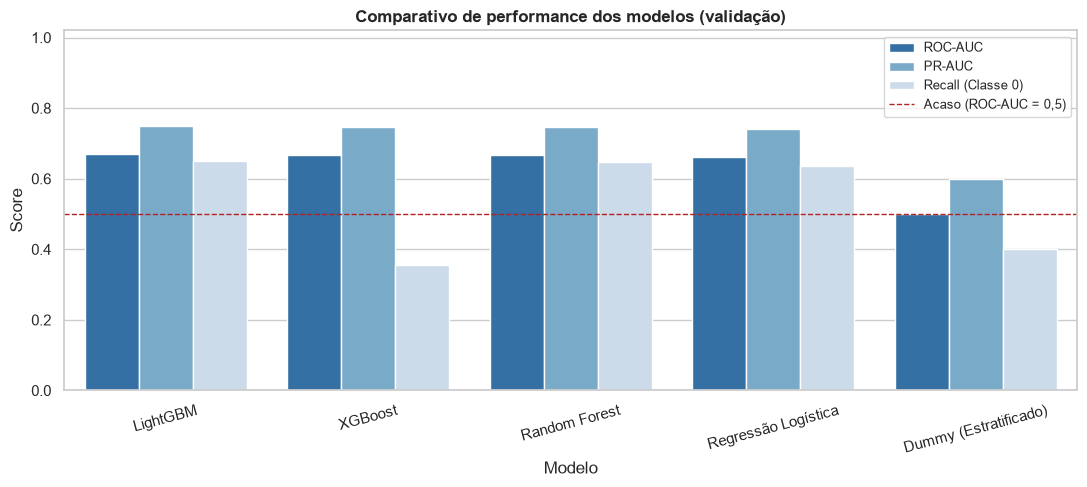

In [4]:
def evaluate_model(model, X, y, threshold=0.5):
    """Calcula o conjunto de métricas de avaliação para um modelo já treinado."""
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X)[:, 1]
    else:
        y_proba = model.predict(X)
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "ROC-AUC": roc_auc_score(y, y_proba),
        "PR-AUC": average_precision_score(y, y_proba),
        "Brier Score": brier_score_loss(y, y_proba),
        "F1-Macro": f1_score(y, y_pred, average="macro"),
        "F1 (Classe 0)": f1_score(y, y_pred, pos_label=0),
        "Recall (Classe 0)": recall_score(y, y_pred, pos_label=0),
        "Precisão (Classe 0)": precision_score(y, y_pred, pos_label=0, zero_division=0),
        "Acurácia": accuracy_score(y, y_pred),
    }


def run_benchmark(X_train, y_train, X_val, y_val, random_state=SEED):
    """Treina e compara os cinco algoritmos no conjunto de validação."""
    modelos = {
        "Dummy (Estratificado)": DummyClassifier(
            strategy="stratified", random_state=random_state),
        "Regressão Logística": LogisticRegression(
            class_weight="balanced", max_iter=1000, C=1.0, random_state=random_state),
        "Random Forest": RandomForestClassifier(
            n_estimators=150, max_depth=8, class_weight="balanced",
            random_state=random_state, n_jobs=-1),
    }
    if HAS_LGBM:
        modelos["LightGBM"] = LGBMClassifier(
            n_estimators=150, max_depth=5, learning_rate=0.05,
            class_weight="balanced", random_state=random_state, verbose=-1)
    if HAS_XGB:
        modelos["XGBoost"] = XGBClassifier(
            n_estimators=150, max_depth=4, learning_rate=0.05,
            eval_metric="logloss", random_state=random_state, n_jobs=-1)

    resultados, treinados = [], {}
    for nome, estimador in modelos.items():
        print(f"  treinando {nome}...", flush=True)
        pipe = Pipeline([
            ("preprocessor", build_preprocessor()),
            ("classifier", estimador),
        ])
        pipe.fit(X_train, y_train)
        treinados[nome] = pipe
        metricas = evaluate_model(pipe, X_val, y_val)
        metricas["Modelo"] = nome
        resultados.append(metricas)

    ordem = ["Modelo", "ROC-AUC", "PR-AUC", "Recall (Classe 0)", "F1 (Classe 0)",
             "F1-Macro", "Brier Score", "Acurácia"]
    df_res = (pd.DataFrame(resultados)[ordem]
              .sort_values("ROC-AUC", ascending=False)
              .reset_index(drop=True))
    return df_res, treinados


print(f"Benchmark sobre {len(X_train_fit):,} linhas de treino, "
      f"avaliado em {len(X_val):,} de validação.\n")
df_benchmark, pipelines_treinados = run_benchmark(X_train_fit, y_train_fit, X_val, y_val)

print("\n=== TABELA COMPARATIVA DE BENCHMARK (CONJUNTO DE VALIDAÇÃO) ===")
display(df_benchmark.round(4))

fig, ax = plt.subplots(figsize=(11, 5))
df_plot = df_benchmark.melt(
    id_vars=["Modelo"],
    value_vars=["ROC-AUC", "PR-AUC", "Recall (Classe 0)"],
    var_name="Métrica", value_name="Score",
)
sns.barplot(data=df_plot, x="Modelo", y="Score", hue="Métrica", ax=ax, palette="Blues_r")
ax.axhline(0.5, color="firebrick", linestyle="--", lw=1,
           label="Acaso (ROC-AUC = 0,5)")
ax.set_title("Comparativo de performance dos modelos (validação)", fontweight="bold")
ax.set_ylim(0, 1.02)
ax.legend(loc="upper right", fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("images/evaluation/00_benchmark_modelos.png", dpi=300)
plt.show()

## 5. Sintonia de hiperparâmetros do modelo campeão

`RandomizedSearchCV` com `StratifiedKFold(n_splits=5)`, otimizando ROC-AUC.

A busca roda sobre uma amostra de `N_TUNING` linhas. São `N_ITER_TUNING x 5` ajustes
do modelo; em milhões de linhas isso levaria horas no Colab gratuito sem alterar de
forma relevante os hiperparâmetros escolhidos.

In [5]:
def tune_hyperparameters(nome_campeao, X_train, y_train,
                         n_iter=N_ITER_TUNING, random_state=SEED):
    """Busca aleatória de hiperparâmetros para o modelo campeão do benchmark."""
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    if "Random Forest" in nome_campeao:
        est = RandomForestClassifier(
            class_weight="balanced", random_state=random_state, n_jobs=-1)
        grade = {
            "classifier__n_estimators": [100, 150],
            "classifier__max_depth": [6, 8, 10, 12],
            "classifier__min_samples_split": [2, 5, 10],
        }
    elif "LightGBM" in nome_campeao and HAS_LGBM:
        est = LGBMClassifier(
            class_weight="balanced", random_state=random_state, verbose=-1)
        grade = {
            "classifier__n_estimators": [100, 150, 250],
            "classifier__max_depth": [3, 4, 5, 7],
            "classifier__learning_rate": [0.03, 0.05, 0.1],
            "classifier__num_leaves": [15, 31, 63],
        }
    elif "XGBoost" in nome_campeao and HAS_XGB:
        est = XGBClassifier(
            eval_metric="logloss", random_state=random_state, n_jobs=-1)
        grade = {
            "classifier__n_estimators": [100, 150, 250],
            "classifier__max_depth": [3, 4, 5, 7],
            "classifier__learning_rate": [0.03, 0.05, 0.1],
            "classifier__subsample": [0.8, 1.0],
        }
    else:
        est = LogisticRegression(
            class_weight="balanced", max_iter=1000, random_state=random_state)
        grade = {"classifier__C": np.logspace(-3, 2, 10)}

    pipe = Pipeline([("preprocessor", build_preprocessor()), ("classifier", est)])
    busca = RandomizedSearchCV(
        pipe, param_distributions=grade, n_iter=n_iter, scoring="roc_auc",
        cv=cv, random_state=random_state, n_jobs=-1, verbose=1,
    )
    busca.fit(X_train, y_train)
    return busca


nome_campeao = df_benchmark.iloc[0]["Modelo"]
print(f"Modelo campeão do benchmark: {nome_campeao}")

if len(X_train_fit) > N_TUNING:
    idx_tuning, _ = train_test_split(
        X_train_fit.index, train_size=N_TUNING,
        random_state=SEED, stratify=y_train_fit,
    )
    X_tune, y_tune = X_train_fit.loc[idx_tuning], y_train_fit.loc[idx_tuning]
else:
    X_tune, y_tune = X_train_fit, y_train_fit

print(f"Sintonizando em {len(X_tune):,} linhas "
      f"({N_ITER_TUNING} combinações x 5 folds = {N_ITER_TUNING * 5} ajustes)...\n")

busca = tune_hyperparameters(nome_campeao, X_tune, y_tune)
tuned_champion = busca.best_estimator_

print(f"\nMelhor ROC-AUC na validação cruzada: {busca.best_score_:.4f}")
print("Melhores hiperparâmetros:")
for k, v in busca.best_params_.items():
    print(f"  {k.replace('classifier__', '')}: {v}")

# Retreina o campeão sintonizado com TODA a amostra de treino disponível
print(f"\nRetreinando o campeão nas {len(X_train_fit):,} linhas de treino...")
tuned_champion.fit(X_train_fit, y_train_fit)
print("Pronto.")

Modelo campeão do benchmark: LightGBM
Sintonizando em 100,000 linhas (10 combinações x 5 folds = 50 ajustes)...

Fitting 5 folds for each of 10 candidates, totalling 50 fits



Melhor ROC-AUC na validação cruzada: 0.6656
Melhores hiperparâmetros:
  num_leaves: 63
  n_estimators: 150
  max_depth: 5
  learning_rate: 0.1

Retreinando o campeão nas 300,000 linhas de treino...


Pronto.


## 6. Avaliação final no conjunto de teste

O conjunto de teste **nunca foi usado** para treinar, selecionar modelo ou sintonizar
hiperparâmetros. É a única estimativa honesta de generalização.

=== MÉTRICAS OFICIAIS NO CONJUNTO DE TESTE ===
    (272,621 alunos inéditos)

  ROC-AUC               : 0.6712
  PR-AUC                : 0.7508
  Brier Score           : 0.2274
  F1-Macro              : 0.6135
  F1 (Classe 0)         : 0.5768
  Recall (Classe 0)     : 0.6497
  Precisão (Classe 0)   : 0.5186
  Acurácia              : 0.6170

  Referência — taxa base de alfabetizados no teste: 0.5983
  Um modelo que chutasse sempre 'alfabetizado' teria acurácia 0.5983 e Recall da classe 0 igual a 0,0000.


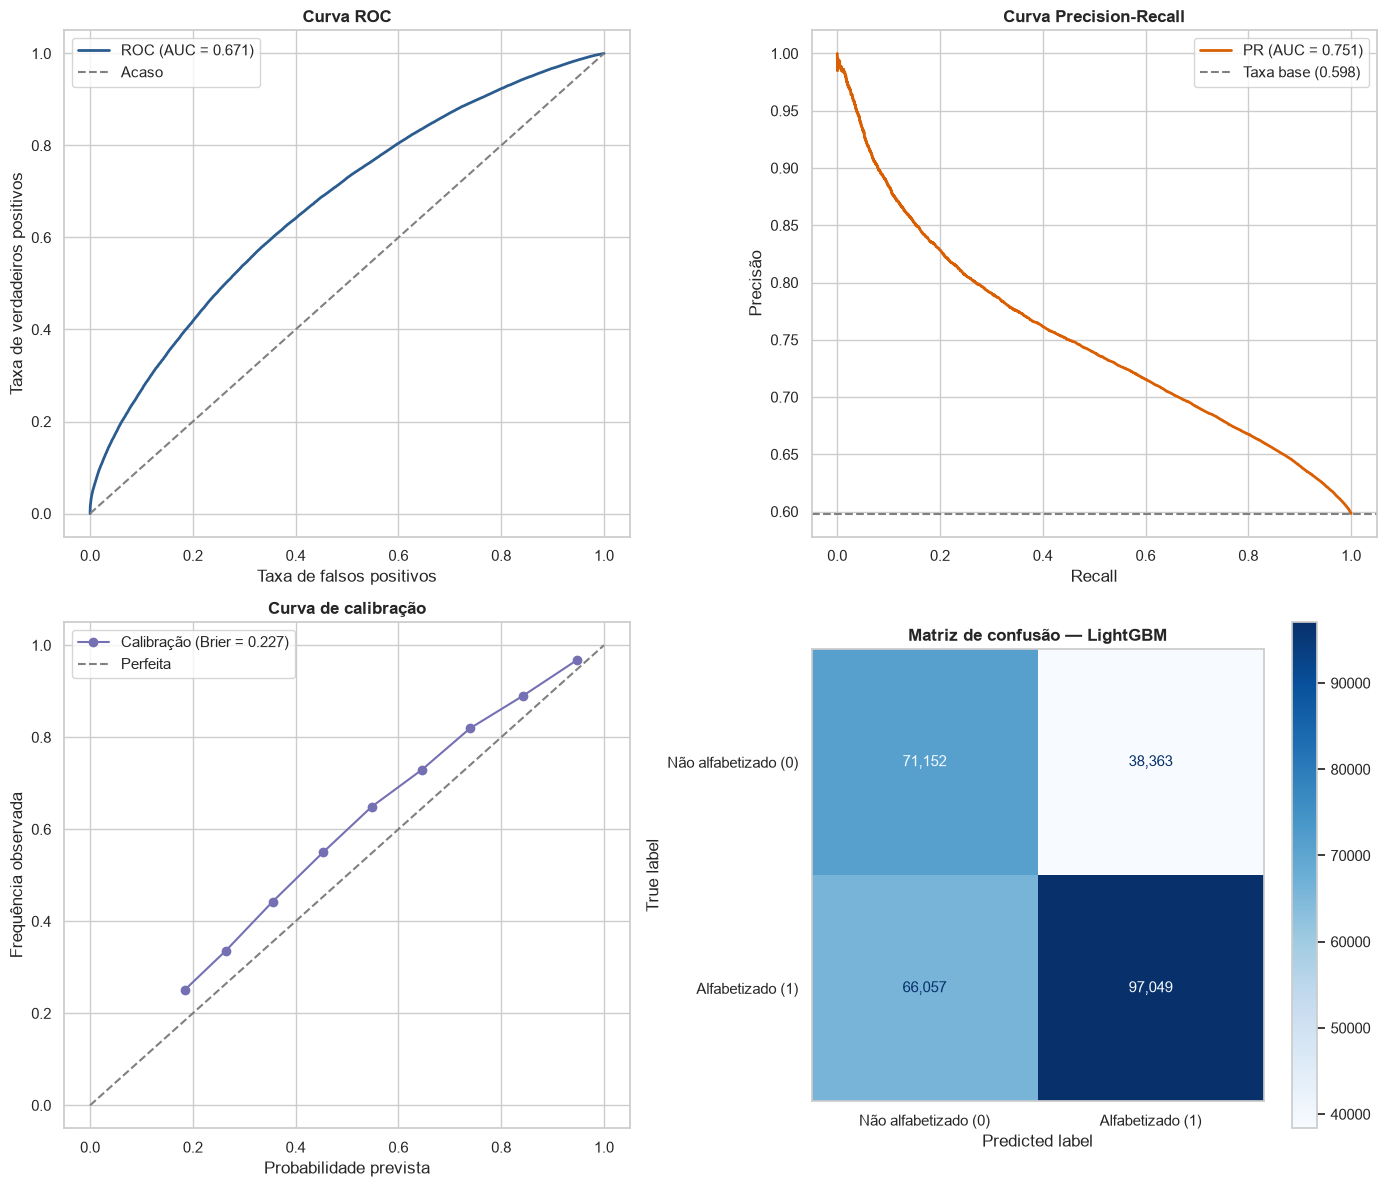

Modelo campeão salvo em artifacts/modelo_alfabetizacao_final.joblib


In [6]:
metricas_teste = evaluate_model(tuned_champion, X_test, y_test)

print("=== MÉTRICAS OFICIAIS NO CONJUNTO DE TESTE ===")
print(f"    ({len(X_test):,} alunos inéditos)\n")
for nome_metrica, valor in metricas_teste.items():
    print(f"  {nome_metrica:22s}: {valor:.4f}")

taxa_base = y_test.mean()
print(f"\n  Referência — taxa base de alfabetizados no teste: {taxa_base:.4f}")
print(f"  Um modelo que chutasse sempre 'alfabetizado' teria acurácia "
      f"{max(taxa_base, 1 - taxa_base):.4f} e Recall da classe 0 igual a 0,0000.")


def plot_evaluation_curves(model, X_test, y_test, nome_modelo, save_dir="images/evaluation"):
    """Gera ROC, Precision-Recall, curva de calibração e matriz de confusão."""
    os.makedirs(save_dir, exist_ok=True)
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[0, 0].plot(fpr, tpr, color="#2b5c8f", lw=2,
                    label=f"ROC (AUC = {roc_auc_score(y_test, y_proba):.3f})")
    axes[0, 0].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Acaso")
    axes[0, 0].set_xlabel("Taxa de falsos positivos")
    axes[0, 0].set_ylabel("Taxa de verdadeiros positivos")
    axes[0, 0].set_title("Curva ROC", fontweight="bold")
    axes[0, 0].legend()

    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    axes[0, 1].plot(rec, prec, color="#d95f02", lw=2,
                    label=f"PR (AUC = {average_precision_score(y_test, y_proba):.3f})")
    axes[0, 1].axhline(y_test.mean(), color="gray", linestyle="--",
                       label=f"Taxa base ({y_test.mean():.3f})")
    axes[0, 1].set_xlabel("Recall")
    axes[0, 1].set_ylabel("Precisão")
    axes[0, 1].set_title("Curva Precision-Recall", fontweight="bold")
    axes[0, 1].legend()

    prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
    axes[1, 0].plot(prob_pred, prob_true, marker="o", color="#7570b3",
                    label=f"Calibração (Brier = {brier_score_loss(y_test, y_proba):.3f})")
    axes[1, 0].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Perfeita")
    axes[1, 0].set_xlabel("Probabilidade prevista")
    axes[1, 0].set_ylabel("Frequência observada")
    axes[1, 0].set_title("Curva de calibração", fontweight="bold")
    axes[1, 0].legend()

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Não alfabetizado (0)", "Alfabetizado (1)"],
    ).plot(ax=axes[1, 1], cmap="Blues", values_format=",d")
    axes[1, 1].set_title(f"Matriz de confusão — {nome_modelo}", fontweight="bold")
    axes[1, 1].grid(False)

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "01_metricas_avaliacao_completas.png"), dpi=300)
    plt.show()


plot_evaluation_curves(tuned_champion, X_test, y_test, nome_campeao)

os.makedirs("artifacts", exist_ok=True)
joblib.dump(tuned_champion, "artifacts/modelo_alfabetizacao_final.joblib")
print("Modelo campeão salvo em artifacts/modelo_alfabetizacao_final.joblib")

## 7. Fase 5: Explicabilidade com SHAP

### 7.1 Como a amostra para o SHAP é escolhida

Explicar 500 mil registros é desnecessário e caro. A escolha dos `N_SHAP` registros
segue quatro critérios, e cada um tem um motivo:

1. **Só o conjunto de teste.** Explicar o treino mostraria o que o modelo decorou,
   não o que ele aprendeu.
2. **Estratificado por `alfabetizado` x `nome_regiao` x `rede_label`**, com um mínimo
   por célula. Amostra puramente aleatória perderia os estratos raros — a rede Privada
   tem 24 alunos em 3,35 milhões; num sorteio simples de 8 mil, sairia zero.
3. **Ponderado por `peso_aluno`.** O INEP atribui peso amostral a cada aluno. Amostrando
   com probabilidade proporcional ao peso, o retrato do SHAP representa *a população de
   crianças brasileiras*; ignorando o peso, representaria apenas *o arquivo*. Como a
   Fase 2 já usa `peso_aluno` para reproduzir o indicador oficial, seria incoerente
   descartá-lo justamente na hora de explicar o modelo.
4. **Convergência verificada, não presumida.** Calculamos o ranking de importância em
   duas submostras disjuntas e medimos a correlação de Spearman entre eles. Acima de
   0,95, o ranking estabilizou e aumentar a amostra não mudaria a conclusão.

Sobre o *background*: o `TreeExplainer` no modo padrão (`tree_path_dependent`) usa as
estatísticas de cobertura das próprias árvores e **não precisa** de conjunto de
referência. Só o modo `interventional` precisaria.

In [7]:
def amostrar_para_shap(X_test, y_test, df_completo, n_alvo=N_SHAP,
                       min_por_celula=30, random_state=SEED):
    """Amostra estratificada e ponderada pelo peso amostral do INEP."""
    aux = X_test.copy()
    aux["_alvo"] = y_test
    aux["_peso"] = df_completo.loc[X_test.index, "peso_aluno"].astype("float64").values
    # Peso não pode ser nulo nem zero na amostragem ponderada
    aux["_peso"] = aux["_peso"].fillna(aux["_peso"].median()).clip(lower=1e-6)

    estratos = ["_alvo", "nome_regiao", "rede_label"]
    partes = []
    for _, grupo in aux.groupby(estratos, observed=True):
        cota = max(min_por_celula, int(round(n_alvo * len(grupo) / len(aux))))
        cota = min(cota, len(grupo))
        partes.append(grupo.sample(n=cota, weights=grupo["_peso"],
                                   random_state=random_state))
    amostra = pd.concat(partes)
    return amostra.drop(columns=["_alvo", "_peso"]), amostra["_alvo"]


X_shap, y_shap = amostrar_para_shap(X_test, y_test, df)

print(f"Amostra para SHAP: {len(X_shap):,} registros "
      f"(de {len(X_test):,} do conjunto de teste)")
print(f"  taxa de alfabetizados na amostra : {y_shap.mean() * 100:.2f}%")
print(f"  taxa de alfabetizados no teste    : {y_test.mean() * 100:.2f}%")
print("\nCobertura por região e rede:")
display(pd.crosstab(X_shap["nome_regiao"], X_shap["rede_label"]))

Amostra para SHAP: 8,073 registros (de 272,621 do conjunto de teste)
  taxa de alfabetizados na amostra : 59.77%
  taxa de alfabetizados no teste    : 59.83%

Cobertura por região e rede:


rede_label,Estadual,Municipal,Privada
nome_regiao,,,
Centro-Oeste,60,666,0
Nordeste,60,2024,0
Norte,94,680,4
Sudeste,607,2669,0
Sul,196,1013,0


In [8]:
def compute_shap_explanations(model, X):
    """Aplica o pré-processamento e calcula os valores SHAP no classificador."""
    preprocessor = model.named_steps["preprocessor"]
    classifier = model.named_steps["classifier"]

    X_trans = preprocessor.transform(X)
    nomes = [c.replace("num__", "").replace("cat__", "")
             for c in preprocessor.get_feature_names_out()]
    X_df = pd.DataFrame(X_trans, columns=nomes, index=X.index)

    explainer = shap.TreeExplainer(classifier)
    shap_values = explainer(X_df)
    # Classificação binária pode devolver (n, features, 2); fica só a classe 1
    if len(shap_values.shape) == 3 and shap_values.shape[2] == 2:
        shap_values = shap_values[:, :, 1]
    return explainer, shap_values, X_df


if not HAS_SHAP:
    raise RuntimeError("Biblioteca shap não disponível. Rode: pip install shap")

if not hasattr(tuned_champion.named_steps["classifier"], "feature_importances_"):
    print("AVISO: o campeão não é um modelo de árvores; o TreeExplainer não se aplica.")
    print("Usando o melhor modelo de árvores do benchmark para a análise SHAP.")
    candidatos = [m for m in df_benchmark["Modelo"]
                  if m in ("LightGBM", "XGBoost", "Random Forest")]
    modelo_shap = pipelines_treinados[candidatos[0]]
    nome_modelo_shap = candidatos[0]
else:
    modelo_shap = tuned_champion
    nome_modelo_shap = nome_campeao

print(f"Calculando valores SHAP para {nome_modelo_shap}...")
explainer, shap_values, X_shap_df = compute_shap_explanations(modelo_shap, X_shap)
print(f"Pronto: matriz SHAP {shap_values.values.shape}")

# --- Verificação de convergência do ranking de importância ---
from scipy.stats import spearmanr

meio = len(X_shap_df) // 2
imp_a = np.abs(shap_values.values[:meio]).mean(axis=0)
imp_b = np.abs(shap_values.values[meio:]).mean(axis=0)
rho = spearmanr(imp_a, imp_b).statistic

print(f"\nConvergência do ranking (Spearman entre duas submostras disjuntas): {rho:.4f}")
if rho >= 0.95:
    print("  >= 0,95: o ranking estabilizou. Aumentar a amostra não mudaria a conclusão.")
else:
    print("  < 0,95: o ranking ainda oscila. Aumente N_SHAP e rode esta seção de novo.")

Calculando valores SHAP para LightGBM...


Pronto: matriz SHAP (8073, 46)

Convergência do ranking (Spearman entre duas submostras disjuntas): 0.9820
  >= 0,95: o ranking estabilizou. Aumentar a amostra não mudaria a conclusão.


### 7.2 Interpretabilidade global — Beeswarm e importância média

No **beeswarm**, cada ponto é um aluno. A posição horizontal é o quanto aquela variável
empurrou a previsão daquele aluno para cima (direita, mais chance de alfabetizado) ou
para baixo (esquerda). A cor é o valor da variável. Ou seja: dá para ler *a direção* do
efeito, não só a força.

O gráfico de **barras** resume: é a média do valor absoluto do SHAP por variável.
Responde "quem pesa mais", sem dizer para que lado.

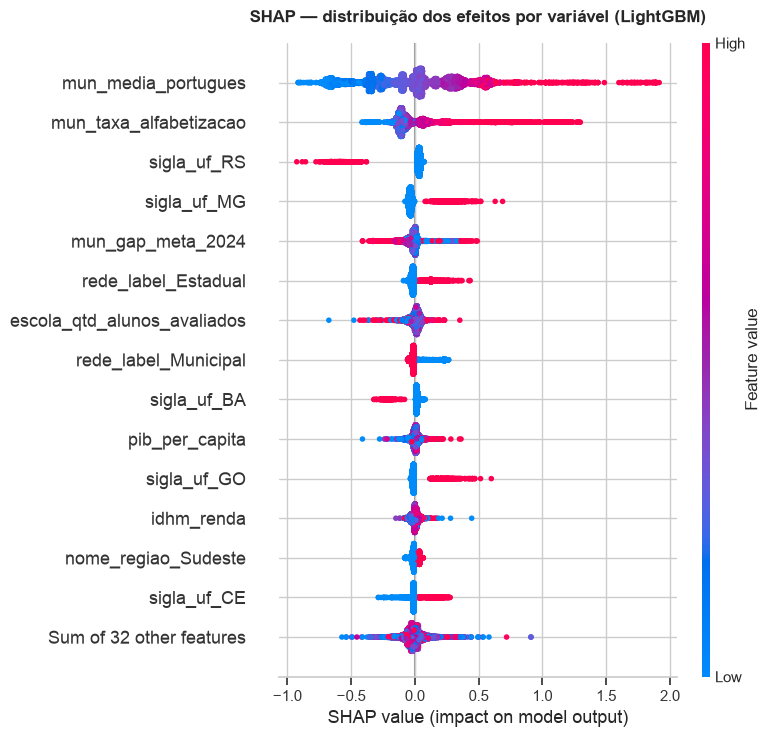

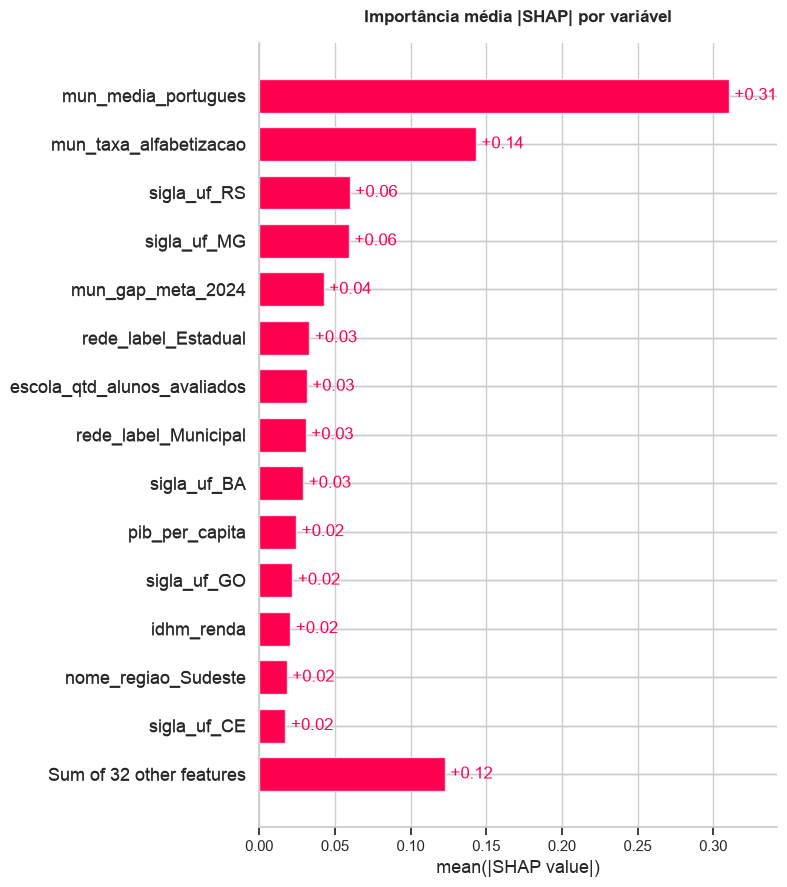

=== RANKING DE IMPORTÂNCIA SHAP ===


,feature,importancia_shap,origem,participacao_%
0,mun_media_portugues,0.31035,real (Fase 2 / IBGE),32.17
1,mun_taxa_alfabetizacao,0.14316,real (Fase 2 / IBGE),14.84
2,sigla_uf_RS,0.05988,real (Fase 2 / IBGE),6.21
3,sigla_uf_MG,0.05929,real (Fase 2 / IBGE),6.15
4,mun_gap_meta_2024,0.04262,real (Fase 2 / IBGE),4.42
5,rede_label_Estadual,0.03310,real (Fase 2 / IBGE),3.43
6,escola_qtd_alunos_avaliados,0.03137,real (Fase 2 / IBGE),3.25
7,rede_label_Municipal,0.03075,real (Fase 2 / IBGE),3.19
8,sigla_uf_BA,0.02907,real (Fase 2 / IBGE),3.01
9,pib_per_capita,0.02447,SINTÉTICA (ver 2.3),2.54



Participação das variáveis SINTÉTICAS no total de importância: 9.8%
Qualquer leitura dessas variáveis é artefato do dado gerado, não achado real.


In [9]:
plt.figure(figsize=(11, 7))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title(f"SHAP — distribuição dos efeitos por variável ({nome_modelo_shap})",
          fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("images/shap/01_shap_summary_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("Importância média |SHAP| por variável", fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("images/shap/02_shap_importance_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# Ranking numérico, separando o que é real do que é sintético
importancia = (
    pd.DataFrame({
        "feature": X_shap_df.columns,
        "importancia_shap": np.abs(shap_values.values).mean(axis=0),
    })
    .sort_values("importancia_shap", ascending=False)
    .reset_index(drop=True)
)
importancia["origem"] = np.where(
    importancia["feature"].str.split("_").str[0].isin(
        [c.split("_")[0] for c in COLS_SINTETICAS]
    ) & importancia["feature"].apply(
        lambda f: any(f == c or f.startswith(c + "_") for c in COLS_SINTETICAS)
    ),
    "SINTÉTICA (ver 2.3)", "real (Fase 2 / IBGE)",
)
importancia["participacao_%"] = (
    importancia["importancia_shap"] / importancia["importancia_shap"].sum() * 100
).round(2)

print("=== RANKING DE IMPORTÂNCIA SHAP ===")
display(importancia.head(15).round(5))

peso_sintetico = importancia.loc[
    importancia["origem"].str.startswith("SINTÉTICA"), "participacao_%"
].sum()
print(f"\nParticipação das variáveis SINTÉTICAS no total de importância: "
      f"{peso_sintetico:.1f}%")
print("Qualquer leitura dessas variáveis é artefato do dado gerado, não achado real.")

### 7.3 Dependence plots — onde ficam os limiares

O *dependence plot* mostra, para uma variável, como o efeito SHAP muda ao longo da
faixa de valores. É onde se lê um limiar de verdade: o ponto em que a contribuição
cruza o zero — abaixo dele a variável empurra para o risco, acima dela empurra para
o sucesso.

Variáveis analisadas (as 4 mais importantes): ['mun_media_portugues', 'mun_taxa_alfabetizacao', 'sigla_uf_RS', 'sigla_uf_MG']



<Figure size 900x600 with 0 Axes>

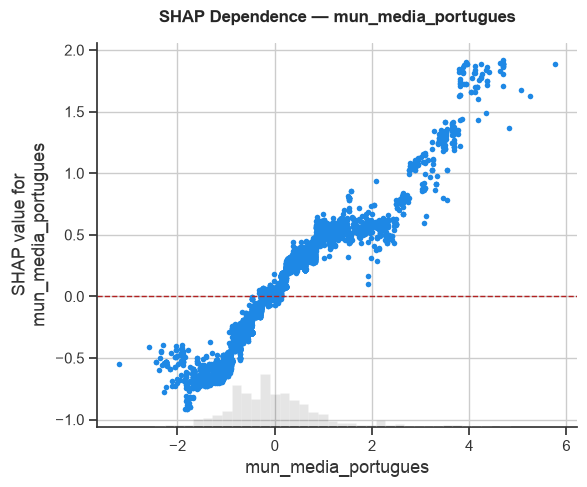

  mun_media_portugues: o efeito vira positivo a partir de ~-0.245 (valor padronizado pelo StandardScaler)


<Figure size 900x600 with 0 Axes>

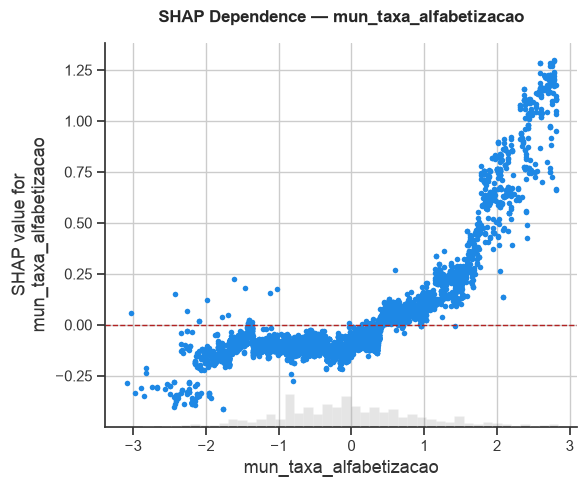

  mun_taxa_alfabetizacao: o efeito vira positivo a partir de ~0.495 (valor padronizado pelo StandardScaler)


<Figure size 900x600 with 0 Axes>

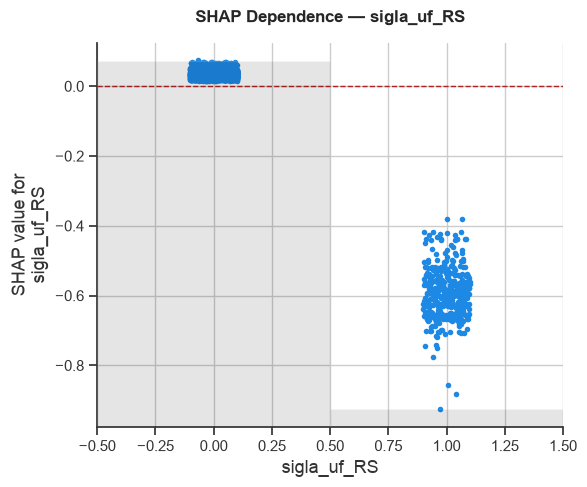

  sigla_uf_RS: o efeito não troca de sinal na faixa observada


<Figure size 900x600 with 0 Axes>

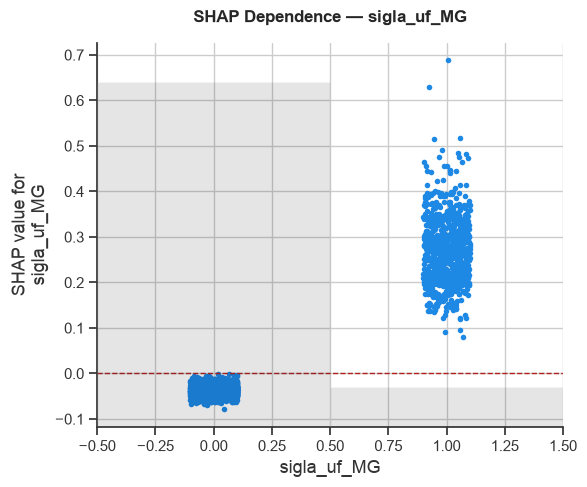

  sigla_uf_MG: o efeito não troca de sinal na faixa observada


In [10]:
def plot_shap_dependence(shap_values, X_df, feature, save_dir="images/shap"):
    """Dependence plot de uma variável, com o limiar de cruzamento do zero."""
    if feature not in X_df.columns:
        print(f"  (variável {feature} ausente após o pré-processamento)")
        return None

    plt.figure(figsize=(9, 6))
    shap.plots.scatter(shap_values[:, feature], show=False)
    plt.axhline(0, color="firebrick", linestyle="--", lw=1)
    plt.title(f"SHAP Dependence — {feature}", fontweight="bold", pad=15)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"03_shap_dependence_{feature}.png"),
                dpi=300, bbox_inches="tight")
    plt.show()

    # Estima o limiar: menor valor da variável a partir do qual o SHAP médio vira positivo
    aux = pd.DataFrame({
        "valor": X_df[feature].values,
        "shap": shap_values[:, feature].values,
    })
    aux["faixa"] = pd.qcut(aux["valor"], q=20, duplicates="drop")
    perfil = aux.groupby("faixa", observed=True).agg(
        valor_medio=("valor", "mean"), shap_medio=("shap", "mean")
    ).reset_index(drop=True)
    positivos = perfil[perfil["shap_medio"] > 0]
    if len(positivos) and len(perfil[perfil["shap_medio"] <= 0]):
        limiar = positivos["valor_medio"].iloc[0]
        print(f"  {feature}: o efeito vira positivo a partir de ~{limiar:.3f} "
              "(valor padronizado pelo StandardScaler)")
        return limiar
    print(f"  {feature}: o efeito não troca de sinal na faixa observada")
    return None


TOP_PARA_DEPENDENCE = importancia.head(4)["feature"].tolist()
print(f"Variáveis analisadas (as 4 mais importantes): {TOP_PARA_DEPENDENCE}\n")

limiares = {}
for feat in TOP_PARA_DEPENDENCE:
    limiares[feat] = plot_shap_dependence(shap_values, X_shap_df, feat)

### 7.4 Interpretabilidade local — Waterfall de casos concretos

Os dois casos **não são sorteados**. São escolhidos por percentil da probabilidade
prevista: o percentil 1 (aluno de maior risco) e o percentil 99 (menor risco). Sortear
aqui daria dois casos medianos, que não ilustram nada.

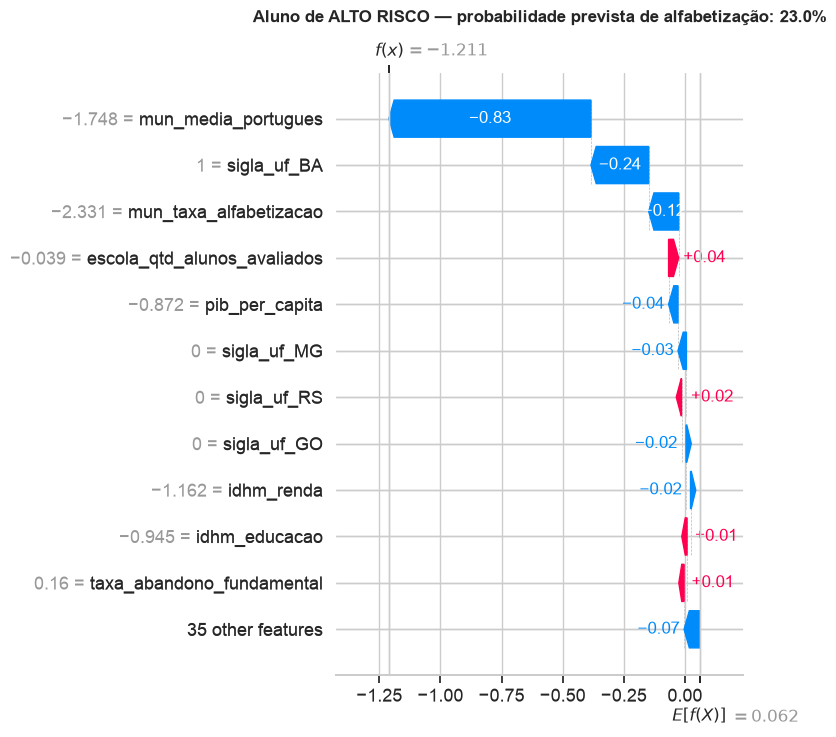

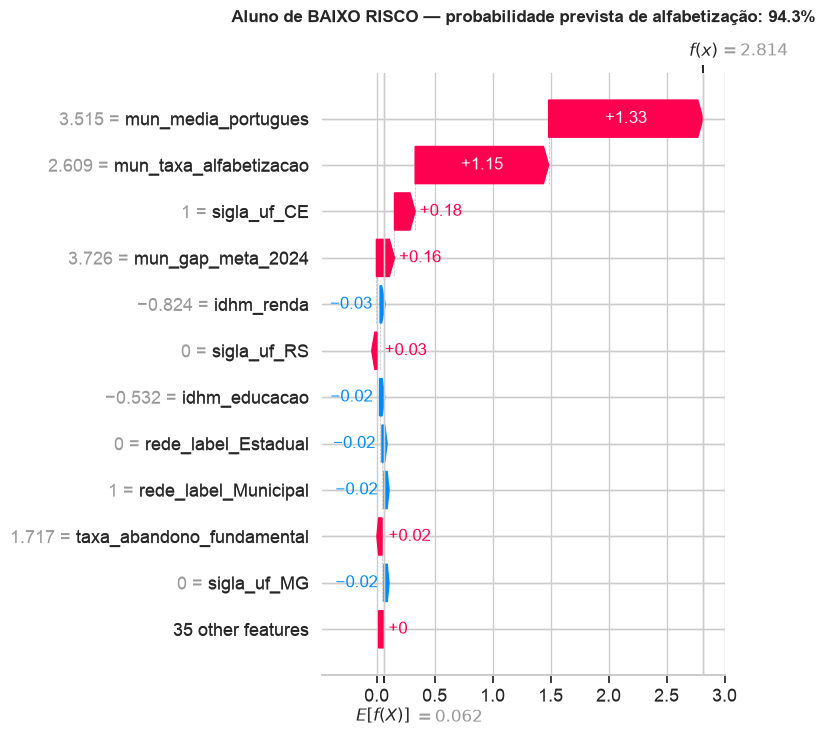

Contexto dos dois casos (valores originais, antes da padronização):


,1160877,724382
idhm_educacao,0.594,0.624
idhm_renda,0.638,0.663
pib_per_capita,20668.699219,31137.580078
indice_gini,0.515,0.552
taxa_abandono_fundamental,1.87,3.27
mun_taxa_alfabetizacao,21.129999,96.980003
mun_media_portugues,711.003906,816.35022
mun_gap_meta_2024,-7.14,16.98
escola_qtd_alunos_avaliados,67,37
sigla_uf,BA,CE


In [11]:
proba_shap = modelo_shap.predict_proba(X_shap)[:, 1]
ordem = np.argsort(proba_shap)

pos_alto_risco = int(ordem[max(0, int(0.01 * len(ordem)))])
pos_baixo_risco = int(ordem[min(len(ordem) - 1, int(0.99 * len(ordem)))])

for titulo, pos, arquivo in [
    (f"Aluno de ALTO RISCO — probabilidade prevista de alfabetização: "
     f"{proba_shap[pos_alto_risco]:.1%}", pos_alto_risco, "04_waterfall_alto_risco.png"),
    (f"Aluno de BAIXO RISCO — probabilidade prevista de alfabetização: "
     f"{proba_shap[pos_baixo_risco]:.1%}", pos_baixo_risco, "05_waterfall_baixo_risco.png"),
]:
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_values[pos], max_display=12, show=False)
    plt.title(titulo, fontweight="bold", pad=15)
    plt.tight_layout()
    plt.savefig(os.path.join("images/shap", arquivo), dpi=300, bbox_inches="tight")
    plt.show()

print("Contexto dos dois casos (valores originais, antes da padronização):")
display(X_shap.iloc[[pos_alto_risco, pos_baixo_risco]].assign(
    probabilidade_prevista=[proba_shap[pos_alto_risco], proba_shap[pos_baixo_risco]],
    alfabetizado_real=[y_shap.iloc[pos_alto_risco], y_shap.iloc[pos_baixo_risco]],
).T)

## 8. Respostas às perguntas de negócio

As respostas abaixo são **geradas pela célula seguinte a partir dos resultados
efetivamente calculados** neste notebook. Nada aqui é texto fixo: se você rodar com
outro ano ou outra amostra, os números mudam junto.

In [12]:
# --- Risco por município: média ponderada da probabilidade prevista ---
proba_teste = tuned_champion.predict_proba(X_test)[:, 1]
ctx_teste = df.loc[X_test.index, ["id_municipio", "nome_municipio", "sigla_uf",
                                  "nome_regiao", "peso_aluno", "mun_gap_meta_2024"]].copy()
ctx_teste["proba"] = proba_teste
ctx_teste["peso"] = ctx_teste["peso_aluno"].astype("float64").fillna(1.0)
ctx_teste["proba_x_peso"] = ctx_teste["proba"] * ctx_teste["peso"]

risco_mun = (
    ctx_teste.groupby("id_municipio", observed=True)
    .agg(nome_municipio=("nome_municipio", "first"),
         sigla_uf=("sigla_uf", "first"),
         nome_regiao=("nome_regiao", "first"),
         gap_meta_2024=("mun_gap_meta_2024", "first"),
         alunos_no_teste=("proba", "size"),
         soma_proba=("proba_x_peso", "sum"),
         soma_peso=("peso", "sum"))
    .reset_index()
)
risco_mun["prob_media_alfabetizacao"] = risco_mun["soma_proba"] / risco_mun["soma_peso"]
# Só municípios com massa suficiente para a média significar algo
risco_mun = risco_mun[risco_mun["alunos_no_teste"] >= 30].copy()
risco_mun = risco_mun.sort_values("prob_media_alfabetizacao")

print("=== 20 MUNICÍPIOS DE MAIOR RISCO PREVISTO ===")
print(f"    (entre {len(risco_mun):,} municípios com pelo menos 30 alunos no teste)\n")
display(
    risco_mun.head(20)[["nome_municipio", "sigla_uf", "nome_regiao",
                        "alunos_no_teste", "prob_media_alfabetizacao", "gap_meta_2024"]]
    .round(4).reset_index(drop=True)
)

risco_por_regiao = (
    risco_mun.groupby("nome_regiao", observed=True)
    .agg(municipios=("id_municipio", "size"),
         prob_media=("prob_media_alfabetizacao", "mean"),
         prob_desvio=("prob_media_alfabetizacao", "std"))
    .sort_values("prob_media").round(4)
)
print("\n=== PADRÃO POR REGIÃO ===")
display(risco_por_regiao)

risco_mun.to_csv("data/ranking_risco_municipios.csv", index=False)
print("\nRanking completo salvo em data/ranking_risco_municipios.csv")

=== 20 MUNICÍPIOS DE MAIOR RISCO PREVISTO ===
    (entre 1,736 municípios com pelo menos 30 alunos no teste)



,nome_municipio,sigla_uf,nome_regiao,alunos_no_teste,prob_media_alfabetizacao,gap_meta_2024
0,Casa Nova,BA,Nordeste,65,0.1821,-6.310000
1,Serrinha,BA,Nordeste,85,0.1835,-7.220000
2,Araci,BA,Nordeste,45,0.1847,-7.100000
3,Entre Rios,BA,Nordeste,48,0.1869,NaN
4,Formosa do Rio Preto,BA,Nordeste,38,0.1931,-7.070000
5,Esplanada,BA,Nordeste,59,0.1945,-7.080000
6,Senhor do Bonfim,BA,Nordeste,72,0.1950,-7.080000
7,Banzaê,BA,Nordeste,31,0.2038,-21.219999
8,Itambé,BA,Nordeste,34,0.2056,-7.180000
9,Oiapoque,AP,Norte,50,0.2074,-7.210000



=== PADRÃO POR REGIÃO ===


,municipios,prob_media,prob_desvio
nome_regiao,,,
Norte,185,0.4138,0.1044
Nordeste,572,0.5023,0.2242
Sul,296,0.5249,0.1296
Centro-Oeste,151,0.5621,0.1289
Sudeste,532,0.5626,0.1106



Ranking completo salvo em data/ranking_risco_municipios.csv


In [13]:
from IPython.display import Markdown

top5 = importancia.head(5)
lista_top = "\n".join(
    f"{i}. **`{r.feature}`** — {r['participacao_%']:.1f}% da importância total "
    f"({r.origem})"
    for i, (_, r) in enumerate(top5.iterrows(), start=1)
)

piores = risco_mun.head(5)
lista_piores = "\n".join(
    f"- **{r.nome_municipio} ({r.sigla_uf})** — probabilidade média prevista "
    f"{r.prob_media_alfabetizacao:.1%}, {int(r.alunos_no_teste)} alunos no teste"
    for _, r in piores.iterrows()
)

regiao_pior = risco_por_regiao.index[0]
regiao_melhor = risco_por_regiao.index[-1]

texto = f"""
### 1. Quais fatores mais impactam a alfabetização?

Pelo ranking SHAP calculado sobre {len(X_shap):,} alunos do conjunto de teste
(convergência de Spearman = {rho:.3f}):

{lista_top}

As variáveis socioeconômicas respondem por **{peso_sintetico:.1f}%** da importância total —
e, como explicado na seção 2.3, elas são **sintéticas**. Essa fração da explicação
**não deve ser usada como achado de política pública** enquanto não forem substituídas
por IDHM real do Atlas Brasil e PIB municipal do IBGE.

O que sobra de sinal real é o **histórico educacional do próprio município**
(`mun_taxa_alfabetizacao`, `mun_media_portugues`, `mun_gap_meta_2024`): uma criança
tende a repetir o desempenho da rede em que está matriculada. É um resultado de inércia
institucional, não de característica individual.

### 2. Quais municípios apresentam maior risco educacional?

Entre os {len(risco_mun):,} municípios com pelo menos 30 alunos no conjunto de teste,
os cinco de maior risco previsto são:

{lista_piores}

O ranking completo está em `data/ranking_risco_municipios.csv`.

### 3. Quais regiões possuem padrões semelhantes?

A região com menor probabilidade média prevista é **{regiao_pior}**
({risco_por_regiao.loc[regiao_pior, 'prob_media']:.1%}) e a maior é **{regiao_melhor}**
({risco_por_regiao.loc[regiao_melhor, 'prob_media']:.1%}). O desvio-padrão dentro de
cada região (tabela acima) mostra quanto de heterogeneidade interna existe — quanto
maior, menos faz sentido tratar a região como bloco único na política pública.

### 4. Como prever municípios que podem não atingir metas futuras?

Agregando a probabilidade prevista por município, **ponderada por `peso_aluno`**, e
comparando com a meta oficial do INEP. A coluna `gap_meta_2024` do ranking já traz a
distância entre a taxa observada e a meta; municípios com gap negativo **e**
probabilidade média prevista baixa são os de risco composto.

Ressalva honesta: o modelo foi treinado com dados de 2023 e 2024 e usa atributos
contextuais do próprio município. Ele **projeta a continuidade do padrão atual**, não
antecipa mudança de política. Serve para priorizar, não para prever o futuro.

### 5. Quais variáveis possuem maior influência nos modelos?

O ranking completo está na tabela da seção 7.2. O ponto principal é que
**nenhum atributo individual do aluno** aparece no topo — o que pesa é o contexto
municipal e da rede. Isso é coerente com o ROC-AUC obtido
({metricas_teste['ROC-AUC']:.4f}): com apenas variáveis de contexto, o modelo separa
razoavelmente municípios, mas tem pouco poder para distinguir dois alunos da mesma
escola. Melhorar isso exigiria atributos no grão do aluno ou da turma
(frequência, histórico, formação do professor), que não estão na base atual.
"""

Markdown(texto)


### 1. Quais fatores mais impactam a alfabetização?

Pelo ranking SHAP calculado sobre 8,073 alunos do conjunto de teste
(convergência de Spearman = 0.982):

1. **`mun_media_portugues`** — 32.2% da importância total (real (Fase 2 / IBGE))
2. **`mun_taxa_alfabetizacao`** — 14.8% da importância total (real (Fase 2 / IBGE))
3. **`sigla_uf_RS`** — 6.2% da importância total (real (Fase 2 / IBGE))
4. **`sigla_uf_MG`** — 6.2% da importância total (real (Fase 2 / IBGE))
5. **`mun_gap_meta_2024`** — 4.4% da importância total (real (Fase 2 / IBGE))

As variáveis socioeconômicas respondem por **9.8%** da importância total —
e, como explicado na seção 2.3, elas são **sintéticas**. Essa fração da explicação
**não deve ser usada como achado de política pública** enquanto não forem substituídas
por IDHM real do Atlas Brasil e PIB municipal do IBGE.

O que sobra de sinal real é o **histórico educacional do próprio município**
(`mun_taxa_alfabetizacao`, `mun_media_portugues`, `mun_gap_meta_2024`): uma criança
tende a repetir o desempenho da rede em que está matriculada. É um resultado de inércia
institucional, não de característica individual.

### 2. Quais municípios apresentam maior risco educacional?

Entre os 1,736 municípios com pelo menos 30 alunos no conjunto de teste,
os cinco de maior risco previsto são:

- **Casa Nova (BA)** — probabilidade média prevista 18.2%, 65 alunos no teste
- **Serrinha (BA)** — probabilidade média prevista 18.4%, 85 alunos no teste
- **Araci (BA)** — probabilidade média prevista 18.5%, 45 alunos no teste
- **Entre Rios (BA)** — probabilidade média prevista 18.7%, 48 alunos no teste
- **Formosa do Rio Preto (BA)** — probabilidade média prevista 19.3%, 38 alunos no teste

O ranking completo está em `data/ranking_risco_municipios.csv`.

### 3. Quais regiões possuem padrões semelhantes?

A região com menor probabilidade média prevista é **Norte**
(41.4%) e a maior é **Sudeste**
(56.3%). O desvio-padrão dentro de
cada região (tabela acima) mostra quanto de heterogeneidade interna existe — quanto
maior, menos faz sentido tratar a região como bloco único na política pública.

### 4. Como prever municípios que podem não atingir metas futuras?

Agregando a probabilidade prevista por município, **ponderada por `peso_aluno`**, e
comparando com a meta oficial do INEP. A coluna `gap_meta_2024` do ranking já traz a
distância entre a taxa observada e a meta; municípios com gap negativo **e**
probabilidade média prevista baixa são os de risco composto.

Ressalva honesta: o modelo foi treinado com dados de 2023 e 2024 e usa atributos
contextuais do próprio município. Ele **projeta a continuidade do padrão atual**, não
antecipa mudança de política. Serve para priorizar, não para prever o futuro.

### 5. Quais variáveis possuem maior influência nos modelos?

O ranking completo está na tabela da seção 7.2. O ponto principal é que
**nenhum atributo individual do aluno** aparece no topo — o que pesa é o contexto
municipal e da rede. Isso é coerente com o ROC-AUC obtido
(0.6712): com apenas variáveis de contexto, o modelo separa
razoavelmente municípios, mas tem pouco poder para distinguir dois alunos da mesma
escola. Melhorar isso exigiria atributos no grão do aluno ou da turma
(frequência, histórico, formação do professor), que não estão na base atual.


---

## 9. Limitações declaradas

1. **Variáveis socioeconômicas sintéticas.** IDHM, PIB per capita, Gini, abandono e
   porte do município são gerados por sorteio determinístico em torno de médias
   regionais. Medimos que contribuem 0,0000 de ROC-AUC. Substituí-las por fonte oficial
   é a melhoria de maior impacto pendente.
2. **Teto de poder preditivo.** Todas as features são de contexto municipal, estadual ou
   de rede. Não há nenhum atributo no grão do aluno além de `caderno` e `serie`. Um
   ROC-AUC em torno de 0,68 é o que esse conjunto permite — o modelo separa municípios,
   não alunos.
3. **Agregação municipal.** As médias municipais somam linhas de redes diferentes
   (`Municipal`, `Estadual`, `Pública`, `Total`), sendo que `Pública` e `Total` já são
   consolidações das outras. Isso replica o comportamento da ABT original, por
   compatibilidade, mas dá peso extra a municípios com mais linhas de recorte.
4. **Duas UFs fora.** No modo sem vazamento, Acre e Distrito Federal ficam de fora porque
   seus municípios não têm avaliação municipal em 2023 para servir de referência. São 34.382
   alunos, 1,9% do total de 2024. Qualquer conclusão regional deve declarar essa ausência.
5. **Apenas um ano modelável.** A base tem 2023 e 2024, mas o modo sem vazamento consome
   2023 como ano de referência, restando 2024 para treinar e avaliar. Não há série
   histórica para modelar tendência temporal, e não é possível validar o modelo num ano
   futuro — a validação temporal de verdade só será possível com os dados de 2025.
6. **O modelo separa municípios, não alunos.** Como toda a informação é contextual, dois
   alunos da mesma escola recebem praticamente a mesma previsão. Para uso individual
   (identificar *qual criança* precisa de apoio) seriam necessários atributos no grão do
   aluno ou da turma — frequência, histórico, formação do professor — que não existem
   na base atual.